In [12]:
import gymnasium as gym

env = gym.make("CartPole-v1", render_mode="human")
print(f"Action space: {env.action_space}")  # Discrete(2) - left or right. Instantiations of Space class
print(f"Sample action: {env.action_space.sample()}")  # 0 or 1
# Box observation space (continuous values)
print(f"Observation space: {env.observation_space}")  # Box with 4 values
# Box([-4.8, -inf, -0.418, -inf], [4.8, inf, 0.418, inf])
print(f"Sample observation: {env.observation_space.sample()}")  # Random valid observation

observation, info = env.reset()
print(observation.shape, observation)

# Example output: [ 0.01234567 -0.00987654  0.02345678  0.01456789]
# [cart_position, cart_velocity, pole_angle, pole_angular_velocity]

episode_over = False
total_reward = 0

while not episode_over:
    # Choose an action: 0 = push cart left, 1 = push cart right
    action = env.action_space.sample()  # Random action for now - real agents will be smarter!

    # Take the action and see what happens. Interestingly, the gym already outputs reward without us using it
    observation, reward, terminated, truncated, info = env.step(action)
    print(observation, reward, terminated, truncated, info)

    # reward: +1 for each step the pole stays upright
    # terminated: True if pole falls too far (agent failed)
    # truncated: True if we hit the time limit (500 steps)

    total_reward += reward
    episode_over = terminated or truncated
print(f"Episode finished! Total reward: {total_reward}")
env.close()


Action space: Discrete(2)
Sample action: 1
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Sample observation: [-3.0679116  -0.9786806  -0.06488271 -1.2003772 ]
(4,) [-0.03127128  0.03199735  0.02931254 -0.00163888]
[-0.03063134  0.22668692  0.02927976 -0.28493112] 1.0 False False {}
[-0.0260976   0.4213793   0.02358114 -0.5682375 ] 1.0 False False {}
[-0.01767001  0.22593467  0.01221639 -0.26821986] 1.0 False False {}
[-0.01315132  0.42088017  0.00685199 -0.5570247 ] 1.0 False False {}
[-0.00473372  0.6159053  -0.0042885  -0.84754103] 1.0 False False {}
[ 0.00758439  0.81108546 -0.02123932 -1.1415695 ] 1.0 False False {}
[ 0.0238061   0.6162474  -0.04407071 -0.85562223] 1.0 False False {}
[ 0.03613105  0.8119413  -0.06118315 -1.1618307 ] 1.0 False False {}
[ 0.05236987  1.0078045  -0.08441976 -1.4730523 ] 1.0 False False {}
[ 0.07252596  1.2038509  -0.11388081 -1.7908646 ] 1.0 False False {}
[ 0.09

In [14]:
#Using wrappers for easy control - Here using it to flatten a space

from gymnasium.wrappers import FlattenObservation

env = gym.make("CarRacing-v3")
print(env.observation_space)

wrapped_env = FlattenObservation(env)
print(wrapped_env.observation_space.shape)

#To get the original spacer
print(wrapped_env.unwrapped)

Box(0, 255, (96, 96, 3), uint8)
(27648,)
<CarRacing<CarRacing-v3>>


In [15]:
#Building blackjack with Q-learning self implementation

from collections import defaultdict
import gymnasium as gym
import numpy as np


class BlackjackAgent:
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        """Initialize a Q-Learning agent.

        Args:
            env: The training environment
            learning_rate: How quickly to update Q-values (0-1)
            initial_epsilon: Starting exploration rate (usually 1.0)
            epsilon_decay: How much to reduce epsilon each episode
            final_epsilon: Minimum exploration rate (usually 0.1)
            discount_factor: How much to value future rewards (0-1)
        """
        self.env = env

        # Q-table: maps (state, action) to expected reward
        # defaultdict automatically creates entries with zeros for new states
        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))

        self.lr = learning_rate
        self.discount_factor = discount_factor  # How much we care about future rewards

        # Exploration parameters
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        # Track learning progress
        self.training_error = []

    def get_action(self, obs: tuple[int, int, bool]) -> int:
        """Choose an action using epsilon-greedy strategy.

        Returns:
            action: 0 (stand) or 1 (hit)
        """
        # With probability epsilon: explore (random action)
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()

        # With probability (1-epsilon): exploit (best known action)
        else:
            return int(np.argmax(self.q_values[obs]))

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):
        """Update Q-value based on experience.

        This is the heart of Q-learning: learn from (state, action, reward, next_state)
        """
        # What's the best we could do from the next state?
        # (Zero if episode terminated - no future rewards possible)
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])

        # What should the Q-value be? (Bellman equation)
        target = reward + self.discount_factor * future_q_value

        # How wrong was our current estimate?
        temporal_difference = target - self.q_values[obs][action]

        # Update our estimate in the direction of the error
        # Learning rate controls how big steps we take
        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )

        # Track learning progress (useful for debugging)
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)


In [31]:
# Training hyperparameters
learning_rate = 0.01        # How fast to learn (higher = faster but less stable)
n_episodes = 100_000        # Number of hands to practice
start_epsilon = 1.0         # Start with 100% random actions
epsilon_decay = start_epsilon / (n_episodes / 2)  # Reduce exploration over time
final_epsilon = 0.1         # Always keep some exploration

# Create environment and agent
env = gym.make("Blackjack-v1", sab=False, render_mode="rgb_array")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = BlackjackAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)


#Training
from tqdm import tqdm  # Progress bar

for episode in tqdm(range(n_episodes)):
    # Start a new hand
    obs, info = env.reset()
    done = False

    # Play one complete hand
    while not done:
        # Agent chooses action (initially random, gradually more intelligent)
        action = agent.get_action(obs)

        # Take action and observe result
        next_obs, reward, terminated, truncated, info = env.step(action)

        # Learn from this experience
        agent.update(obs, action, reward, terminated, next_obs)

        # Move to next state
        done = terminated or truncated
        obs = next_obs

    # Reduce exploration rate (agent becomes less random over time)
    agent.decay_epsilon()





100%|██████████| 100000/100000 [00:14<00:00, 6698.98it/s]


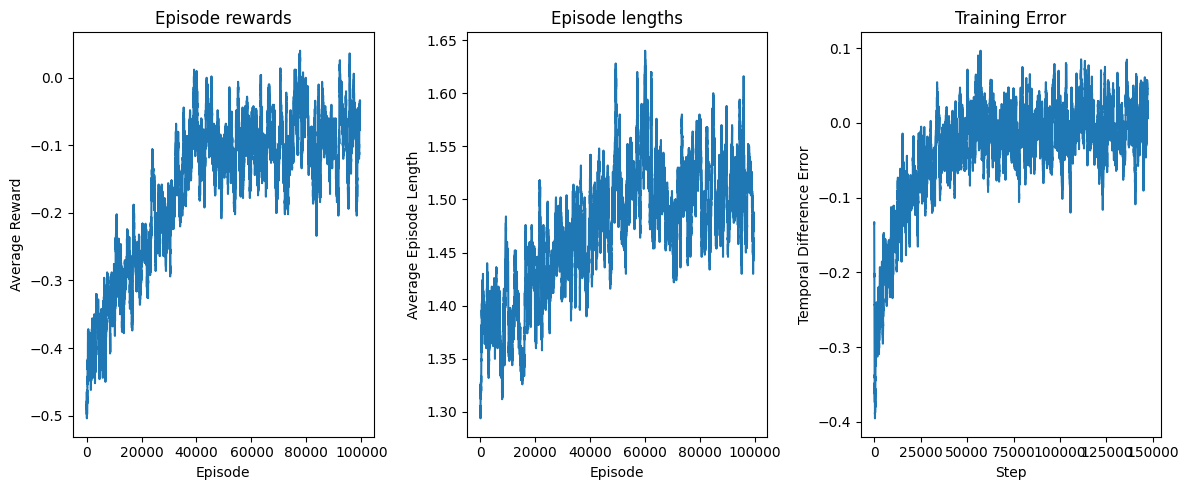

In [32]:
#Analyze results

from matplotlib import pyplot as plt

def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [44]:
#I construct new env here and let the trained agent take actions

#I prob do not see any video because the length is only max 2 steps, so there is nothing to show here

import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo
import numpy as np

# Configuration
num_eval_episodes = 2
eval_env_name = "Blackjack-v1"  # Environment the agent was trained on

# Create a fresh environment for evaluation
eval_env = gym.make(eval_env_name, render_mode="rgb_array")  # rgb_array needed for video recording

# Add video recording for every episode
eval_env = RecordVideo(
    eval_env,
    video_folder="trained-agent",    # Folder to save videos
    name_prefix="eval",               # Prefix for video filenames
    episode_trigger=lambda x: True    # Record every episode
)

# Add episode statistics tracking
eval_env = RecordEpisodeStatistics(eval_env, buffer_length=num_eval_episodes)

print(f"Starting evaluation for {num_eval_episodes} episodes...")
print(f"Videos will be saved to: trained-agent/")

for episode_num in range(num_eval_episodes):
    obs, info = eval_env.reset()
    episode_reward = 0
    step_count = 0

    episode_over = False
    while not episode_over:
        # Replace this with your trained agent's policy

        obs, reward, terminated, truncated, info = eval_env.step(agent.get_action(obs))
        episode_reward += reward
        step_count += 1

        episode_over = terminated or truncated

    print(f"Episode {episode_num + 1}: {step_count} steps, reward = {episode_reward}")

eval_env.close()

# Print summary statistics
print(f'\nEvaluation Summary:')
print(f'Episode durations: {list(eval_env.time_queue)}')
print(f'Episode rewards: {list(eval_env.return_queue)}')
print(f'Episode lengths: {list(eval_env.length_queue)}')

# Calculate some useful metrics
avg_reward = np.sum(eval_env.return_queue)
avg_length = np.sum(eval_env.length_queue)
std_reward = np.std(eval_env.return_queue)

print(f'\nAverage reward: {avg_reward:.2f} \u00b1 {std_reward:.2f}')
print(f'Average episode length: {avg_length:.1f} steps')
print(f'Success rate: {sum(1 for r in eval_env.return_queue if r > 0) / len(eval_env.return_queue):.1%}')

Starting evaluation for 2 episodes...
Videos will be saved to: trained-agent/
Episode 1: 2 steps, reward = 1.0
Episode 2: 1 steps, reward = -1.0

Evaluation Summary:
Episode durations: [0.035426, 0.016496]
Episode rewards: [1.0, -1.0]
Episode lengths: [2, 1]

Average reward: 0.00 ± 1.00
Average episode length: 3.0 steps
Success rate: 50.0%


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /content/trained-agent folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
